# Model Comparison


In [1]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv(r'..\dataset\WELFake_Cleaned.csv')

X = df['Cleaned']
Y = df['label']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size = 0.2, random_state = 42, stratify = Y
)

vectorizer = joblib.load(r'..\models\tfidf_vectorizer.pkl')

X_test_tfidf = vectorizer.transform(X_test)

Loading models

In [7]:
log_reg = joblib.load(r'..\models\logistic_regression_model.pkl')
multi_nb = joblib.load(r'..\models\Multinomial_Naive_Bayes_model.pkl')
lin_svm = joblib.load(r'..\models\Linear_SVM_model.pkl')

In [14]:
import time

In [15]:
start = time.time()
Y_pred_lr = log_reg.predict(X_test_tfidf)
lr_time = round(time.time() - start, 4)

start = time.time()
Y_pred_mnb = multi_nb.predict(X_test_tfidf)
mnb_time = round(time.time() - start, 4)

start = time.time()
Y_pred_svm = lin_svm.predict(X_test_tfidf)
svm_time = round(time.time() - start, 4)

In [16]:
lr_results = {
    'Accuracy' : round(accuracy_score(Y_test,Y_pred_lr),4),
    'Precision': round(precision_score(Y_test,Y_pred_lr),4),
    'Recall': round(recall_score(Y_test,Y_pred_lr),4),
    'F1 Score': round(f1_score(Y_test,Y_pred_lr),4),
    'Inference Time (s)': lr_time
}
mnb_results = {
    'Accuracy' : round(accuracy_score(Y_test,Y_pred_mnb),4),
    'Precision': round(precision_score(Y_test,Y_pred_mnb),4),
    'Recall': round(recall_score(Y_test,Y_pred_mnb),4),
    'F1 Score': round(f1_score(Y_test,Y_pred_mnb),4),
    'Inference Time (s)': mnb_time
}
svm_results = {
    'Accuracy' : round(accuracy_score(Y_test,Y_pred_svm),4),
    'Precision': round(precision_score(Y_test,Y_pred_svm),4),
    'Recall': round(recall_score(Y_test,Y_pred_svm),4),
    'F1 Score': round(f1_score(Y_test,Y_pred_svm),4),
    'Inference Time (s)': svm_time
}

In [17]:
pd.DataFrame([lr_results,mnb_results,svm_results],index=('Log_reg','Multi_nb','Lin_svm'))

,Accuracy,Precision,Recall,F1 Score,Inference Time (s)
Log_reg,0.9525,0.9459,0.9626,0.9541,0.0089
Multi_nb,0.8568,0.8443,0.8845,0.8639,0.0113
Lin_svm,0.9554,0.9518,0.9620,0.9569,0.0526


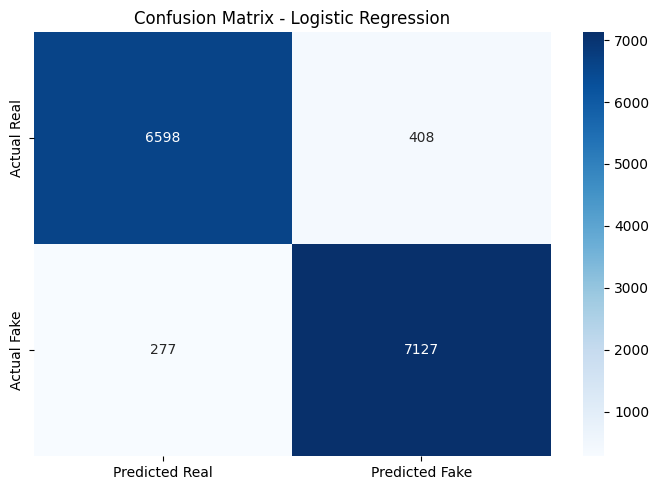

In [18]:
lr_cm = confusion_matrix(Y_test, Y_pred_lr)

plt.figure(figsize=(7,5))
sns.heatmap(
    lr_cm, annot=True,fmt='d',cmap='Blues',xticklabels=['Predicted Real','Predicted Fake'],yticklabels=['Actual Real','Actual Fake']
)
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

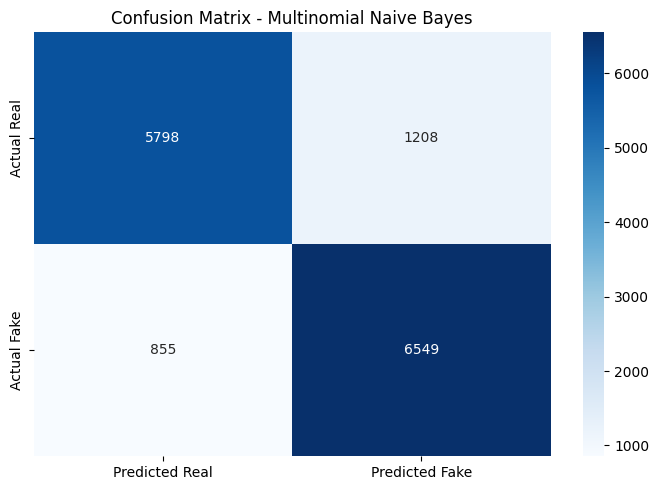

In [20]:
mnb_cm = confusion_matrix(Y_test, Y_pred_mnb)

plt.figure(figsize=(7,5))
sns.heatmap(
    mnb_cm, annot=True,fmt='d',cmap='Blues',xticklabels=['Predicted Real','Predicted Fake'],yticklabels=['Actual Real','Actual Fake']
)
plt.title('Confusion Matrix - Multinomial Naive Bayes')
plt.tight_layout()
plt.show()

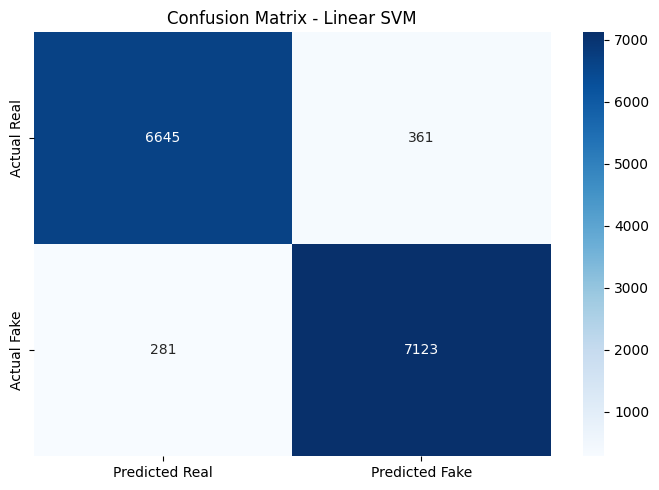

In [21]:
svm_cm = confusion_matrix(Y_test, Y_pred_svm)

plt.figure(figsize=(7,5))
sns.heatmap(
    svm_cm, annot=True,fmt='d',cmap='Blues',xticklabels=['Predicted Real','Predicted Fake'],yticklabels=['Actual Real','Actual Fake']
)
plt.title('Confusion Matrix - Linear SVM')
plt.tight_layout()
plt.show()

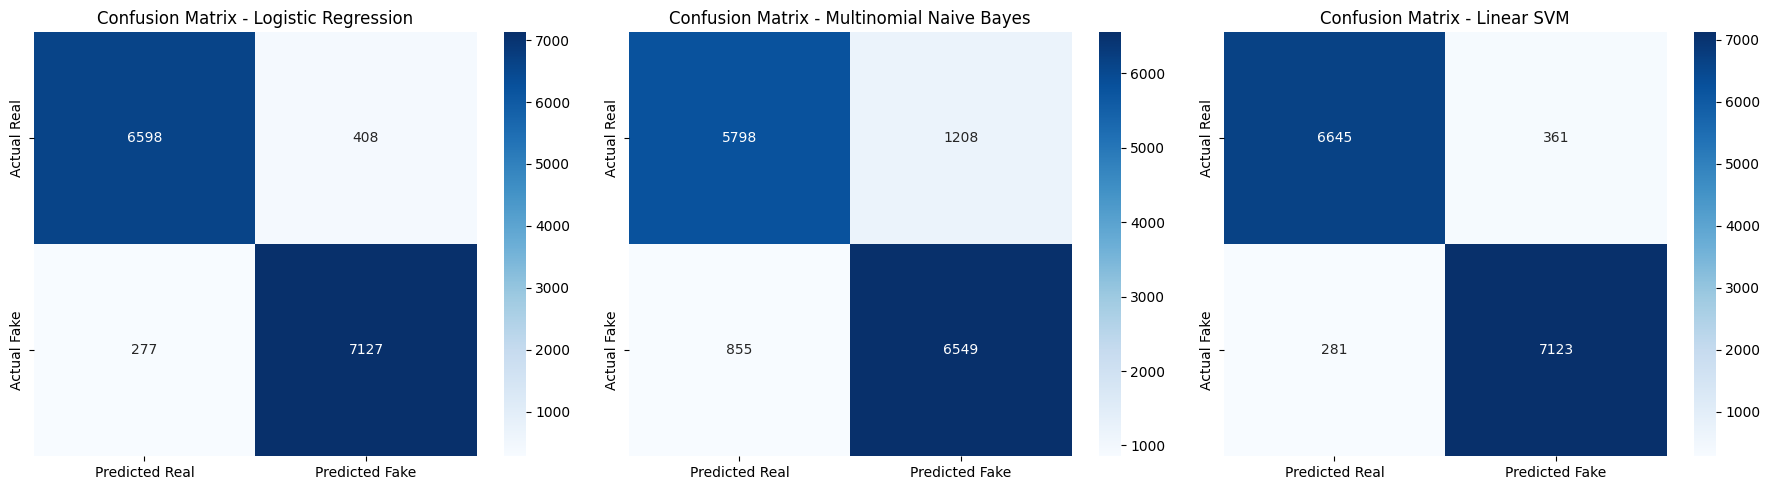

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cm, title in zip(axes,
    [lr_cm, mnb_cm, svm_cm],
    ['Logistic Regression', 'Multinomial Naive Bayes', 'Linear SVM']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Predicted Real', 'Predicted Fake'],
        yticklabels=['Actual Real', 'Actual Fake'],
        ax=ax)
    ax.set_title(f'Confusion Matrix - {title}')

plt.tight_layout()
plt.savefig(r'..\screenshots\confusion_matrix_comparison.png', dpi=150)
plt.show()

In [24]:
error_df = pd.DataFrame({
    'text': X_test,
    'actual': Y_test,
    'lr_pred': Y_pred_lr
}).reset_index(drop=True)

# False Positives — Real articles flagged as Fake
fp = error_df[(error_df['actual'] == 0) & (error_df['lr_pred'] == 1)]

# False Negatives — Fake articles that slipped through as Real
fn = error_df[(error_df['actual'] == 1) & (error_df['lr_pred'] == 0)]

print(f"False Positives (Real → Fake): {len(fp)}")
print(f"False Negatives (Fake → Real): {len(fn)}")

print("\n--- 5 FALSE POSITIVES ---")
for i, row in fp.head(5).iterrows():
    print(f"\n[{i}] {row['text'][:200]}\n")

print("\n--- 5 FALSE NEGATIVES ---")
for i, row in fn.head(5).iterrows():
    print(f"\n[{i}] {row['text'][:200]}\n")

False Positives (Real → Fake): 408
False Negatives (Fake → Real): 277

--- 5 FALSE POSITIVES ---

[57] ashton carter sworn obamas th defense secretary ashton carter sworn obamas th defense secretary cold snow walloped washington overnight didnt stop ashton carter reporting work tuesday carter sworn th 


[73] factbox us intel report russian cyber attacks election reuters declassified report us intelligence agencies said russian president vladimir putin ordered effort help donald trumps electoral chances di


[124] robert creamer sues james okeefe project veritas sting breitbart robert creamer democracy partners consulting group sued conservative filmmaker james okeefe project veritas thursday district columbia 


[202] german vicechancellor eu breaking apart longer unthinkable german sigmar gabriel said longer unthinkable eu break apart light brexit referendum migrant crisis ongoing troubles eurozone still owes answ


[264] internet living great firewall china reuters great firewall ch

ERROR ANALYSIS FINDINGS
=======================

FALSE POSITIVES (Real → Fake): 408
- Genuine news articles misclassified as fake
- Common pattern: articles covering politically charged topics
  (elections, cyber attacks, political figures) where fake-leaning
  tokens outweigh source attribution signals like 'reuters'
- Shows the model is a weighted combination of signals, not purely
  source fingerprinting

FALSE NEGATIVES (Fake → Real): 277  
- Fake/misleading articles that slipped through as real
- Common pattern: partisan opinion and political commentary
- These articles lack obvious fabrication markers but use
  emotionally charged, informal language
- Key finding: the model cannot distinguish between fake news
  and partisan opinion content — both share similar token
  distributions and lack wire service vocabulary

CONCLUSION
- Misclassifications are not random — they cluster around
  politically charged content and opinion writing
- Accuracy alone does not capture these failure modes
- A source-neutral dataset and contextual model (BERT) would
  be needed to address both categories of error